In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
import sunpy.map
import pathlib

# Explorative Analisis

In [2]:
print(a.jsoc.Series)

sunpy.net.jsoc.attrs.Series

The JSOC Series to Download.

           Attribute Name           ...
----------------------------------- ...
aia_flatfield                       ...
aia_lev1                            ...
aia_lev1_euv_12s                    ...
aia_lev1_uv_24s                     ...
aia_lev1_vis_1h                     ...
aia_master_pointing3h               ...
aia_response                        ...
aia_temperature_summary_300s        ...
hmi_b_135s                          ...
hmi_b_5760s                         ...
hmi_b_720s                          ...
hmi_b_720s_dcon                     ...
hmi_b_720s_dcons                    ...
hmi_b_720s_e15w1332_cea             ...
hmi_b_720s_e15w1332_cutout          ...
hmi_b_90s                           ...
hmi_b_synoptic                      ...
hmi_b_synoptic_small                ...
hmi_bharp_720s                      ...
hmi_bharp_720s_nrt                  ...
hmi_bmap_lowres_latlon_720s         ...
hmi_bptr_720s_mod    

## Download SDO Data — 2026-04-01

Downloads one snapshot per channel from the **Solar Dynamics Observatory (SDO)**:

| Channel | Instrument | Observable | Series |
|---|---|---|---|
| Continuum | HMI | Intensitygram | `hmi.Ic_45s` |
| Doppler | HMI | LOS velocity | `hmi.V_45s` |
| Magnetogram | HMI | LOS magnetic field | `hmi.M_45s` |
| AIA | AIA | EUV + UV images | 9 wavelength channels |

Data is fetched via **VSO** using `sunpy.net.Fido`. All images are full-disk (4096 × 4096 px).

In [3]:
# Single snapshot: noon UTC on 2026-04-01 (1-hour window guarantees exactly one frame per series)
t_start = '2026-04-01 12:00:00'
t_end   = '2026-04-01 12:10:00'
time_range = a.Time(t_start, t_end)

### HMI — Continuum, Doppler, Magnetogram

In [4]:
# HMI Continuum (intensitygram) — visible-light image of the photosphere
result_continuum = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.intensity,
)
print("=== Continuum ===")
print(result_continuum)

# HMI Dopplergram — line-of-sight velocity (photospheric convection & flows)
result_doppler = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_velocity,
)
print("\n=== Doppler ===")
print(result_doppler)

# HMI Magnetogram — line-of-sight magnetic field strength
result_magnetogram = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_magnetic_field,
)
print("\n=== Magnetogram ===")
print(result_magnetogram)

=== Continuum ===
Results from 1 Provider:

13 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                         Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- --------- -------- ------------ ------------- ----------- --------
2026-04-01 12:00:30.000 2026-04-01 12:00:31.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2026-04-01 12:01:15.000 2026-04-01 12:01:16.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2026-04

### AIA — EUV and UV channels

AIA observes the Sun at 9 wavelength channels covering the chromosphere, transition region, and corona.

| Wavelength (Å) | Region | Cadence |
|---|---|---|
| 94 | Flaring corona (~6 MK) | 12 s |
| 131 | Flaring / hot loops (~10 MK) | 12 s |
| 171 | Quiet corona / upper TR (~0.6 MK) | 12 s |
| 193 | Corona / hot flare plasma (~1.2 MK) | 12 s |
| 211 | Active region corona (~2 MK) | 12 s |
| 304 | Chromosphere / TR (~0.05 MK) | 12 s |
| 335 | Active region corona (~2.5 MK) | 12 s |
| 1600 | Upper photosphere / TR | 24 s |
| 1700 | Temperature minimum / photosphere | 24 s |

In [5]:
#aia_wavelengths = [94, 131, 171, 193, 211, 304, 335, 1600, 1700]  # Angstrom
aia_wavelengths = [94]
results_aia = {}
for wl in aia_wavelengths:
    results_aia[wl] = Fido.search(
        time_range,
        a.Instrument.aia,
        a.Wavelength(wl * u.angstrom),
    )
    print(f"=== AIA {wl} Å ===")
    print(results_aia[wl])

=== AIA 94 Å ===
Results from 1 Provider:

50 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport
Total estimated size: 3.389 Gbyte

       Start Time               End Time        Source Instrument  Wavelength  Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                    Angstrom                                                                       Mibyte 
----------------------- ----------------------- ------ ---------- ------------ -------- --------- -------- ------------ ------------- ----------- --------
2026-04-01 12:00:11.000 2026-04-01 12:00:12.000    SDO        AIA 94.0 .. 94.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844
2026-04-01 12:00:23.000 2026-04-01 12:00:24.000    SDO        AIA 94.0 .. 94.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.

In [6]:
download_dir = pathlib.Path('../data/raw/2026-04-01')
download_dir.mkdir(parents=True, exist_ok=True)

# --- Uncomment to trigger the actual download (~134 MB) ---

if download_dir.exists():
    print(f"Directory {download_dir} already exists. Skipping download.")
else:
    files_continuum   = Fido.fetch(result_continuum,   path=download_dir)
    files_doppler     = Fido.fetch(result_doppler,     path=download_dir)
    files_magnetogram = Fido.fetch(result_magnetogram, path=download_dir)

# for now we won't download the AIA data
# files_aia = {}
# for wl, result in results_aia.items():
#     files_aia[wl] = Fido.fetch(result, path=download_dir)

print(f"Download directory: {download_dir.resolve()}")

Directory ../data/raw/2026-04-01 already exists. Skipping download.
Download directory: /home/thomas/Desktop/sun_spots_pulsation_review/data/raw/2026-04-01


In [ ]:
# Source - https://stackoverflow.com/a/54529216
# Posted by Mc Missile, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-17, License - CC BY-SA 4.0

from astropy.io import fits
import numpy as np

def make_cube(pattern, output_path, overwrite=False):

    """
    Combine a series of FITS files matching the given pattern into a single 3D cube.

    Parameters:
    - pattern: A glob pattern to match the input FITS files (e.g., "data/*.fits").
    - output_path: The path where the output cube FITS file will be saved.
    - overwrite: If True, overwrite the output file if it already exists.

    Returns:
    - The path to the created cube FITS file.
    """
    import glob
    from astropy.io import fits

    # Find all files matching the pattern
    file_list = sorted(glob.glob(str(pattern)))
    if not file_list:
        raise ValueError(f"No files found matching pattern: {pattern}")

    # Read the first file to get dimensions and header
    with fits.open(file_list[0]) as hdu:
        data_shape = hdu[1].data.shape
        header = hdu[1].header.copy()

    # Initialize an empty cube
    cube = np.zeros((len(file_list), *data_shape))

    # Fill the cube with data from each file
    for i, file in enumerate(file_list):
        with fits.open(file) as hdu:
            cube[i] = hdu[1].data

    # Write the cube to a new FITS file
    # output_verify='silentfix' silently fixes non-standard header values (e.g. string 'nan' in CRDER/CSYSER cards)
    hdu_new = fits.PrimaryHDU(cube, header=header)
    hdu_new.writeto(output_path, overwrite=overwrite, output_verify='silentfix')

ImportError: attempted relative import with no known parent package

In [8]:
make_cube(download_dir / 'hmi.ic_45s.2026.04.*.continuum.fits', download_dir / 'hmi_continuum_cube.fits', overwrite=True)

In [10]:
make_cube(download_dir / 'hmi.m_45s.2026.04.*.magnetogram.fits', download_dir / 'hmi_magnetogram_cube.fits', overwrite=True)
make_cube(download_dir / 'hmi.v_45s.2026.04.*.Dopplergram.fits', download_dir / 'hmi_doppler_cube.fits', overwrite=True)

then run 
```bash
ds9 *cube* 
```
in orther to see the 3 cubes in total each cube has 12 frames that is about 9 minutes no pulsation is appernt, the easiest chanel to identufy sunspot is continios and also magnetogram, but the doplegram does't show relevant information maybe a nonlinar scale will work

as next step we recopilate the cordinates of each sunspot taking an area of each sunspot and enlogating it on the direction of movement in other to take into acount the rotacion of the sun, with this we eill be able to dowload at leat 1 horur of data from those especifir sunspots

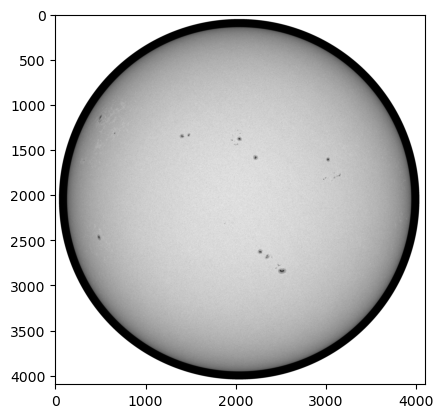

In [ ]:
file_list = sorted(download_dir.glob('hmi.ic_45s.2026.04.*.continuum.fits'))


with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

## Download especif data of each sunstop